# Parameter Estimation NLE
To do parameter estimation, we can use vapor pressure model from previous [example](<../Simulation NLE>).
For parameter estimation we need: model and experimental data.
Model is defined exactly as in previous section.

## Model creation

In [45]:
import mopeds
import numpy as np
import copy

variable_list = mopeds.VariableList()

variable_list.add_variable(mopeds.VariableAlgebraic("T", 373.0))
variable_list.add_variable(mopeds.VariableParameter("A", 3.55959, -1e3, 1e3))
variable_list.add_variable(mopeds.VariableParameter("B", 643.748, -1e3, 1e3))
variable_list.add_variable(mopeds.VariableParameter("C", -198.043, -1e4, 1e4))
variable_list.add_variable(mopeds.VariableControl("p", 1.0, 0.5, 3))
m = mopeds.Model(variable_list)

T = m.varlist_all["T"].casadi_var
A = m.varlist_all["A"].casadi_var
B = m.varlist_all["B"].casadi_var
C = m.varlist_all["C"].casadi_var
p = m.varlist_all["p"].casadi_var

EQ_alg1 = p - 10**(A - (B / (T + C)))

list_algebraic_equations = [EQ_alg1]
m.add_equations_algebraic(list_algebraic_equations)

## Providing data

Data has to be provided using a variable list, by providing a value for algebraic variables, that are measured. Algebraic variables without value will be ignored. Assuming we have pressure and temperature values in lists `artificial_controls` and `artificial_data`, we need following code to provide data.

In [47]:
aritifical_controls = [
    0.5,
    0.7777777777777778,
    1.0555555555555556,
    1.3333333333333335,
    1.6111111111111112,
    1.8888888888888888,
    2.166666666666667,
    2.4444444444444446,
    2.7222222222222223,
    3.0
]

artificial_data = [
    364.2997132128273,
    373.87219318788704,
    380.0266106144029,
    385.3865747086218,
    388.8613013531244,
    393.87775354360167,
    396.4967576258504,
    400.0184640940616,
    403.5469424859316,
    407.15753640547916
]

list_varlist = []

for p, T in zip(artificial_controls, artificial_data):
    varlist_new = copy.deepcopy(variable_list)
    varlist_new["p"].value = p
    varlist_new["T"].value = T
    list_varlist.append(varlist_new)

list_varlist[0]["A"].fixed = False
list_varlist[0]["C"].fixed = False

pe = mopeds.ParameterEstimationNLE(m, list_varlist)
res_pe = pe.optimize()

print("Resulting parameters: ", res_pe["x_dict"])

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        2
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        2
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  4.7634132e+00 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

## Parameter Uncertainty
Approximated parameter uncertainty can be acessed using parameter analysis method. 

OLS std:  [0.59402026]
[0.04194976 2.40232875]
3.577158156819992 +- 0.09673631506515662 |  (2.7042783915138067%)
-198.62576341510206 +- 5.539780034017858 |  (-2.7890541180402852%)


array([0.09673632, 5.53978003])

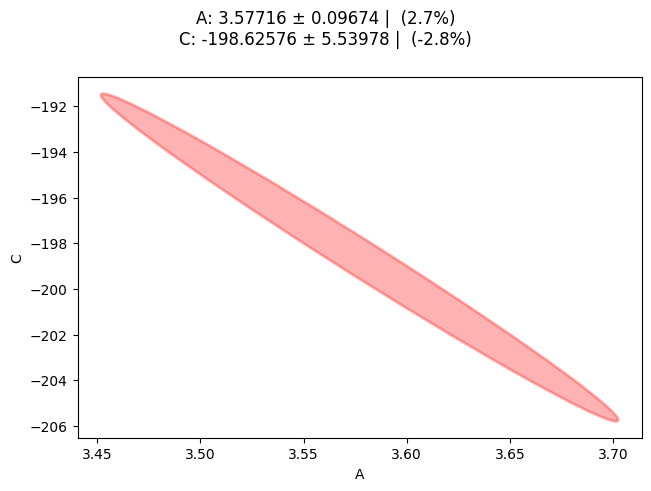

In [48]:
pe.parameter_analysis(res_pe["x_dict"])

Be carefull, parameter uncertainty is calculated using the error of measurements provided using `.variance` attribute of variables. So if we modify the variance, we get different estimation of parameter error

OLS std:  [0.59402026]
[0.13265678 7.59683054]
3.577158156819992 +- 0.30590708805756134 |  (8.551679144360378%)
-198.62576341510206 +- 17.518322643821882 |  (-8.81976353047961%)


array([ 0.30590709, 17.51832264])

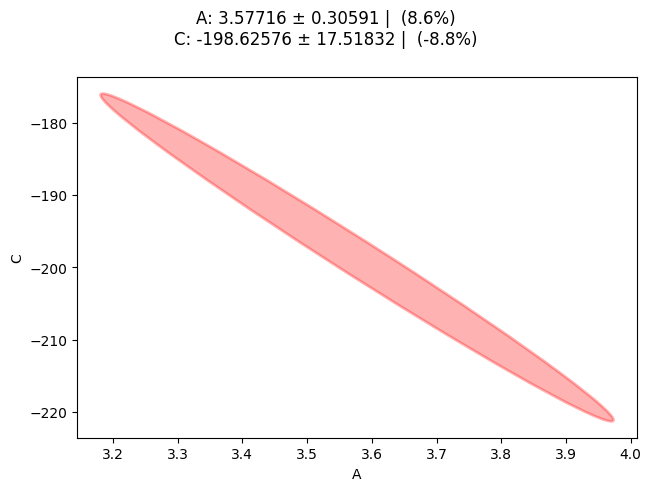

In [49]:
for varlist in list_varlist:
    varlist["T"].variance = 10
    
pe_big_variance = mopeds.ParameterEstimationNLE(m, list_varlist)
pe_big_variance.parameter_analysis(res_pe["x_dict"])

## Artificial Data Generation
Data used above is generated using "true parameters" and some perturbation.

In [51]:
sim = mopeds.SimulatorNLE(m, variable_list)
artificial_data = []
artificial_controls = []
for val in np.linspace(0.5, 3, 10):
    artificial_controls.append(val)
    sim.change_independent_variables({"p": val})
    artificial_data.append(sim.generate_exp_data()["T"].value[0] + np.random.normal())

print("Temperatures: ", artificial_data)
print("Pressures: ", artificial_controls)

Temperatures:  [365.00489672822744, 373.645577864221, 379.65338216280537, 385.61113702797763, 390.1355889893782, 394.37530150979006, 399.74458148275346, 400.97071305255736, 403.80493372898036, 406.617552861875]
Pressures:  [0.5, 0.7777777777777778, 1.0555555555555556, 1.3333333333333335, 1.6111111111111112, 1.8888888888888888, 2.166666666666667, 2.4444444444444446, 2.7222222222222223, 3.0]
